# Module loading

In [1]:
import torch
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os 

In [2]:
from pathlib import Path
import sys
import torch
import numpy as np
import os 

repo_root = Path.cwd().resolve()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from config.config_main import config as path_config

root = path_config.root

import torch.nn as nn
cos = nn.CosineSimilarity(dim=1, eps=1e-6)


r6i2n0


In [ ]:
map_models_name = {"facenet_vggface2_templates" : "FaceNet (VGGFace2)", "facenet_casia_templates" : "FaceNet (Casia)",
 "arcface_r50_templates": "ArcFace-R50 (MS1MV3)", "adaface_vit_templates": "AdaFace-ViT (WebFace42M)"}

In [ ]:
def split_ori_ano(ori, ano, n_samples=50, val_ratio=0.8, test_ratio=0.2):
    """
    Split original and anomaly tensors into train, validation, and test sets with binary labels.

    Args:
        ori (torch.Tensor): Original data tensor.
        ano (torch.Tensor): Anomaly data tensor.
        n_samples (int): Maximum number of samples to use for train+val (default: 50).
        val_ratio (float): Ratio of train+val to use for training (default: 0.8).
        test_ratio (float): Ratio of data to use for testing (default: 0.2).

    Returns:
        tuple: (X_train, y_train, X_val, y_val, X_test, y_test)
    """
    # Calculate splits
    train_test_split = min(int((1 - test_ratio) * ori.size(0)), n_samples)
    train_val_split = int(val_ratio * train_test_split)

    # Train set
    X_train = torch.cat([ori[:train_test_split][:train_val_split],
                         ano[:train_test_split][:train_val_split]], dim=0)
    y_train = torch.cat([torch.zeros(train_val_split),
                         torch.ones(train_val_split)], dim=0).unsqueeze(1)

    # Validation set
    X_val = torch.cat([ori[:train_test_split][train_val_split:],
                       ano[:train_test_split][train_val_split:]], dim=0)
    y_val = torch.cat([torch.zeros(train_test_split - train_val_split),
                       torch.ones(train_test_split - train_val_split)], dim=0).unsqueeze(1)

    # Test set
    X_test = torch.cat([ori[train_test_split:],
                        ano[train_test_split:]], dim=0)
    y_test = torch.cat([torch.zeros(ori.size(0) - train_test_split),
                        torch.ones(ano.size(0) - train_test_split)], dim=0).unsqueeze(1)

    # print("Shapes - Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
    return X_train, y_train, X_val, y_val, X_test, y_test

In [32]:
methods = ["G2Face", "iFADIT", "RiDDLE",
"controlnet_segmentation_masks_mask_anonymized_face_controlnet_inversion",
            ]
models = ["facenet_vggface2_templates", "facenet_casia_templates", "arcface_r50_templates", "adaface_vit_templates"]

facef = {method: {model : {"clean": torch.empty(0), "ano" : torch.empty(0), "reco": torch.empty(0)} for model in models} for method in methods}
DATASET = "CelebA_HQ" # "LFW", "CelebA_HQ"

for method in methods:
    if "controlnet" in method:
        results_dir = os.path.join(root, "results", DATASET, "controlnet_segmentation_masks_mask_anonymized_face_controlnet_inversion")
        for i in range(12):
            if DATASET == "LFW" and i>0:
                break
            r = torch.load(os.path.join(results_dir, f"results_part_{i}.pt"))
            for model in models:
                for facef_type, new_facef_type in zip(["clean", "anonymized", "reconstructed"], ["clean", "ano", "reco"]):
                    facef[method][model][new_facef_type] = torch.cat([facef[method][model][new_facef_type], r[model][facef_type]])
    elif "G2Face" in method:
        results_dir = os.path.join(root, "ext_ano", "G2Face", "results", DATASET, "without_mtcnn")
        r = torch.load(os.path.join(results_dir, f"results.pt"))
        for model in models:
            for facef_type, new_facef_type in zip(["clean", "anonymized", "reconstructed"], ["clean", "ano", "reco"]):
                facef[method][model][new_facef_type] = torch.cat([facef[method][model][new_facef_type], r[model][facef_type]])
    elif "iFADIT" in method:
        results_dir = os.path.join(root, "ext_ano", "iFADIT", "results", DATASET)
        r = torch.load(os.path.join(results_dir, f"results.pt"))
        for model in models:
            for facef_type, new_facef_type in zip(["clean", "anonymized", "reconstructed"], ["clean", "ano", "reco"]):
                facef[method][model][new_facef_type] = torch.cat([facef[method][model][new_facef_type], r[model][facef_type]])
    elif "RiDDLE" in method:
        results_dir = os.path.join(root, "ext_ano", "RiDDLE", "results", DATASET, "additional_data")
        r = torch.load(os.path.join(results_dir, f"results.pt"))
        for model in models:
            for facef_type, new_facef_type in zip(["clean", "anonymized", "reconstructed"], ["clean", "ano", "reco"]):
                facef[method][model][new_facef_type] = torch.cat([facef[method][model][new_facef_type], r[model][facef_type]])        

# Linear of pair-wise plain-image and cipher image

In [6]:
model = "adaface_vit_templates" #["facenet_vggface2_templates", "facenet_casia_templates", "arcface_r50_templates", "adaface_vit_templates"]
method = "controlnet_segmentation_masks_mask_anonymized_face_controlnet_inversion" #["controlnet_segmentation_masks_mask_anonymized_face_controlnet_inversion", "G2Face", "iFADIT"]

In [8]:
# latents = torch.load('weights/arcface_latents.pt')
ori = facef[method][model]["clean"]
ano = facef[method][model]["ano"]
ori.shape, ano.shape

(torch.Size([30000, 512]), torch.Size([30000, 512]))

## Classification

In [9]:
n_samples = 50
train_test_split = min(int(0.8 * ori.size(0)), n_samples)
train_val_split = int(0.8 * train_test_split)
X_train = torch.cat([ori[:train_test_split][:train_val_split], ano[:train_test_split][:train_val_split]], dim=0)
y_train = torch.cat([torch.zeros(train_val_split), torch.ones(train_val_split)], dim=0).unsqueeze(1)
X_val = torch.cat([ori[:train_test_split][train_val_split:], ano[:train_test_split][train_val_split:]], dim=0)
y_val = torch.cat([torch.zeros(train_test_split - train_val_split), torch.ones(train_test_split - train_val_split)], dim=0).unsqueeze(1)
X_test = torch.cat([ori[train_test_split:], ano[train_test_split:]], dim=0)
y_test = torch.cat([torch.zeros(ori.size(0) - train_test_split), torch.ones(ano.size(0) - train_test_split)], dim=0).unsqueeze(1)

print(X_train.shape, X_val.shape, X_test.shape)

torch.Size([80, 512]) torch.Size([20, 512]) torch.Size([59900, 512])


In [10]:
train_test_split

50

In [175]:
linear = torch.nn.Linear(ori.shape[1], 1, bias=True)
optimizer = torch.optim.Adam(linear.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = torch.nn.BCEWithLogitsLoss()

In [176]:
best_loss = float("inf")
patience = 3
counter = 0

for epoch in range(5):
    linear.train()
    optimizer.zero_grad()
    outputs = linear(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    linear.eval()
    with torch.no_grad():
        val_outputs = linear(X_val)
        val_loss = criterion(val_outputs, y_val)

        print(f'Epoch [{epoch+1}/200], Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}')
    
    # if val_loss < best_loss:
    #     best_loss = val_loss
    #     counter = 0
    #     torch.save(model.state_dict(), "best.pt")
    # else:
    #     counter += 1
    #     if counter >= patience:
    #         model.load_state_dict(torch.load("best.pt"))
    #         break



Epoch [1/200], Loss: 0.7603, Val Loss: 0.7952
Epoch [2/200], Loss: 0.7268, Val Loss: 0.7677
Epoch [3/200], Loss: 0.6952, Val Loss: 0.7417
Epoch [4/200], Loss: 0.6655, Val Loss: 0.7172
Epoch [5/200], Loss: 0.6377, Val Loss: 0.6942


In [177]:
yhat = (torch.sigmoid(linear(ori[:train_test_split])) >=0.5)*1.0
true = yhat == 0
train_acc = true.sum().item() / true.size(0)
print(f'Train Accuracy ori : {train_acc:.4f}')

yhat = (torch.sigmoid(linear(ano[:train_test_split])) >=0.5)*1.0
true = yhat == 1
train_acc = true.sum().item() / true.size(0)
print(f'Train Accuracy ano : {train_acc:.4f}')

yhat = (torch.sigmoid(linear(X_test)) >=0.5)*1.0
true = yhat == y_test
test_acc = true.sum().item() / true.size(0)
print(f'Test Accuracy: {test_acc:.4f}')

Train Accuracy ori : 0.7000
Train Accuracy ano : 0.5600
Test Accuracy: 0.6106


In [178]:
w = linear.weight.detach().cpu()[0]
b = linear.bias.detach().cpu()
w.shape, b.shape
torch.save({'weight': w, 'bias': b}, 'weights/linear_boundary.pt')

In [179]:
score = torch.matmul(ano[train_test_split:], w.T) + b
score

C:\Users\Pol\AppData\Local\Temp\ipykernel_31296\971430389.py:1: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4416.)
  score = torch.matmul(ano[train_test_split:], w.T) + b


tensor([0.0145, 0.0511, 0.1482,  ..., 1.1797, 0.7165, 0.4021])

In [180]:
delta = score.reshape(-1, 1) / torch.dot(w, w) * w
x_boundary = ano[train_test_split:] - 2*delta
print(torch.sigmoid(linear(x_boundary)))
x_other_side = x_boundary - 0 * w / torch.dot(w, w)
print(torch.sigmoid(linear(x_other_side)))

tensor([[0.4964],
        [0.4872],
        [0.4630],
        ...,
        [0.2351],
        [0.3282],
        [0.4008]], grad_fn=<SigmoidBackward0>)
tensor([[0.4964],
        [0.4872],
        [0.4630],
        ...,
        [0.2351],
        [0.3282],
        [0.4008]], grad_fn=<SigmoidBackward0>)


In [181]:
yhat = (torch.sigmoid(linear(x_other_side)) >=0.5)*1.0
true = yhat == 0
train_acc = true.sum().item() / true.size(0)
print(f'Train Accuracy: {train_acc:.4f}')

Train Accuracy: 0.5666


In [15]:
model = "adaface_vit_templates" #["facenet_vggface2_templates", "facenet_casia_templates", "arcface_r50_templates", "adaface_vit_templates"]
criterion = torch.nn.BCEWithLogitsLoss()
nsamples = 10
for method in methods:
    ori = facef[method][model]["clean"]
    ano = facef[method][model]["ano"]
    X_train, y_train, X_val, y_val, X_test, y_test = split_ori_ano(ori, ano, n_samples=nsamples)

    linear = torch.nn.Linear(ori.shape[1], 1, bias=True)
    optimizer = torch.optim.Adam(linear.parameters(), lr=1e-3, weight_decay=1e-4)


    for epoch in range(100):
        linear.train()
        optimizer.zero_grad()
        outputs = linear(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()

        linear.eval()
        with torch.no_grad():
            val_outputs = linear(X_val)
            val_loss = criterion(val_outputs, y_val)

            if epoch%10 == 0:
                print(f'Epoch [{epoch+1}/200], Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}')

    yhat = (torch.sigmoid(linear(X_test)) >=0.5)*1.0
    true = yhat == y_test
    test_acc = true.sum().item() / true.size(0)
    print(method, f'Test Accuracy: {test_acc:.4f}')

Shapes - Train: torch.Size([16, 512]) Val: torch.Size([4, 512]) Test: torch.Size([59980, 512])
Epoch [1/200], Loss: 0.8531, Val Loss: 0.8017
Epoch [11/200], Loss: 0.4253, Val Loss: 0.6372
Epoch [21/200], Loss: 0.2226, Val Loss: 0.5347
Epoch [31/200], Loss: 0.1270, Val Loss: 0.4745
Epoch [41/200], Loss: 0.0813, Val Loss: 0.4333
Epoch [51/200], Loss: 0.0579, Val Loss: 0.4030
Epoch [61/200], Loss: 0.0447, Val Loss: 0.3802
Epoch [71/200], Loss: 0.0363, Val Loss: 0.3624
Epoch [81/200], Loss: 0.0305, Val Loss: 0.3480
Epoch [91/200], Loss: 0.0261, Val Loss: 0.3359
controlnet_segmentation_masks_mask_anonymized_face_controlnet_inversion Test Accuracy: 0.6081
Shapes - Train: torch.Size([16, 512]) Val: torch.Size([4, 512]) Test: torch.Size([59980, 512])
Epoch [1/200], Loss: 0.8934, Val Loss: 0.7210
Epoch [11/200], Loss: 0.4297, Val Loss: 0.7143
Epoch [21/200], Loss: 0.2135, Val Loss: 0.7095
Epoch [31/200], Loss: 0.1211, Val Loss: 0.6943
Epoch [41/200], Loss: 0.0780, Val Loss: 0.6845
Epoch [51/200

In [ ]:
model = "adaface_vit_templates" #["facenet_vggface2_templates", "facenet_casia_templates", "arcface_r50_templates", "adaface_vit_templates"]
from sklearn.svm import SVC
linear = SVC(kernel="linear")
nsamples = 50
for method in methods:
    ori = facef[method][model]["clean"]
    ano = facef[method][model]["ano"]
    X_train, y_train, X_val, y_val, X_test, y_test = split_ori_ano(ori, ano, n_samples=nsamples)

    linear.fit(X_train, y_train)


    yhat = linear.predict(X_test)
    # print(yhat.shape, y_test.shape)
    true = yhat == y_test[:,0].numpy()
    test_acc = true.sum().item() / true.shape[0]
    # print(yhat)
    print(method, f'Test Accuracy: {test_acc:.4f}')

Shapes - Train: torch.Size([80, 512]) Val: torch.Size([20, 512]) Test: torch.Size([59900, 512])


/lustre/fshomisc/sup/hpe/pub/miniforge/24.11.3/envs/pytorch-gpu-2.8.0+py3.12.11/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


controlnet_segmentation_masks_mask_anonymized_face_controlnet_inversion Test Accuracy: 0.6973
Shapes - Train: torch.Size([80, 512]) Val: torch.Size([20, 512]) Test: torch.Size([59900, 512])


/lustre/fshomisc/sup/hpe/pub/miniforge/24.11.3/envs/pytorch-gpu-2.8.0+py3.12.11/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


G2Face Test Accuracy: 0.9139
Shapes - Train: torch.Size([80, 512]) Val: torch.Size([20, 512]) Test: torch.Size([59900, 512])


/lustre/fshomisc/sup/hpe/pub/miniforge/24.11.3/envs/pytorch-gpu-2.8.0+py3.12.11/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


iFADIT Test Accuracy: 0.9618
Shapes - Train: torch.Size([80, 512]) Val: torch.Size([20, 512]) Test: torch.Size([59900, 512])


/lustre/fshomisc/sup/hpe/pub/miniforge/24.11.3/envs/pytorch-gpu-2.8.0+py3.12.11/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


RiDDLE Test Accuracy: 0.9458


In [37]:
model = "adaface_vit_templates" #["facenet_vggface2_templates", "facenet_casia_templates", "arcface_r50_templates", "adaface_vit_templates"]
tested_models = ["arcface_r50_templates", "adaface_vit_templates"]
from sklearn.svm import SVC
# from sklearn.model_selection import KFold
# kf = KFold(n_splits=2)
# kf.get_n_splits()
B = 5
methods = ["RiDDLE", "controlnet_segmentation_masks_mask_anonymized_face_controlnet_inversion"]

nsamples = [5,10,20,40,100]
perf = {method: {model : {nsample : [] for nsample in nsamples} for model in tested_models} for method in methods}
perf_reco = {method: {model : {nsample : None for nsample in nsamples} for model in tested_models} for method in methods}
linear_models = {method: {model : {nsample : None for nsample in nsamples} for model in tested_models} for method in methods}
for model in tested_models:
    for method in methods:
        for nsample in nsamples:
            reco = facef[method][model]["reco"]
            for b in range(B):
                linear = SVC(kernel="linear")

                ori = facef[method][model]["clean"]
                ano = facef[method][model]["ano"]
                perm = torch.randperm(ori.shape[0])
                ori = ori[perm]
                ano = ano[perm]
                # perm = torch.randperm(ori.shape[0])
                # ano = ano[perm]

                X_train, y_train, X_val, y_val, X_test, y_test = split_ori_ano(ori, ano, n_samples=nsample, val_ratio=1)

                linear.fit(X_train, y_train)
                if b == 0:
                    linear_models[method][model][nsample] = linear


                yhat = linear.predict(X_test)
                # print(yhat.shape, y_test.shape)
                true = yhat == y_test[:,0].numpy()
                test_acc = true.sum().item() / true.shape[0]
                perf[method][model][nsample].append(test_acc)

            yhat_reco = linear.predict(reco)
            perf_reco[method][model][nsample] = yhat_reco.mean()
            # perf_reco[method][model][nsample] = yhat_reco # if you want to compared against good de-anonymization

        # print(yhat)
        # print(method, f'Test Accuracy: {test_acc:.4f}')

/lustre/fshomisc/sup/hpe/pub/miniforge/24.11.3/envs/pytorch-gpu-2.8.0+py3.12.11/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/lustre/fshomisc/sup/hpe/pub/miniforge/24.11.3/envs/pytorch-gpu-2.8.0+py3.12.11/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/lustre/fshomisc/sup/hpe/pub/miniforge/24.11.3/envs/pytorch-gpu-2.8.0+py3.12.11/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/lus

In [7]:
perf_reco

{'G2Face': {'arcface_r50_templates': {5: np.float32(0.14953333),
   10: np.float32(0.25266665),
   20: np.float32(0.2451),
   40: np.float32(0.23586667),
   100: np.float32(0.21736667)},
  'adaface_vit_templates': {5: np.float32(0.40283334),
   10: np.float32(0.3605),
   20: np.float32(0.2634),
   40: np.float32(0.1458),
   100: np.float32(0.12703334)}},
 'iFADIT': {'arcface_r50_templates': {5: np.float32(0.9989333),
   10: np.float32(0.9865),
   20: np.float32(0.9694333),
   40: np.float32(0.97966665),
   100: np.float32(0.97943336)},
  'adaface_vit_templates': {5: np.float32(0.98053336),
   10: np.float32(0.9436),
   20: np.float32(0.94983333),
   40: np.float32(0.97536665),
   100: np.float32(0.91646665)}},
 'RiDDLE': {'arcface_r50_templates': {5: np.float32(0.95266664),
   10: np.float32(0.40373334),
   20: np.float32(0.64603335),
   40: np.float32(0.48623332),
   100: np.float32(0.3821)},
  'adaface_vit_templates': {5: np.float32(0.12256667),
   10: np.float32(0.50963336),
   20: 

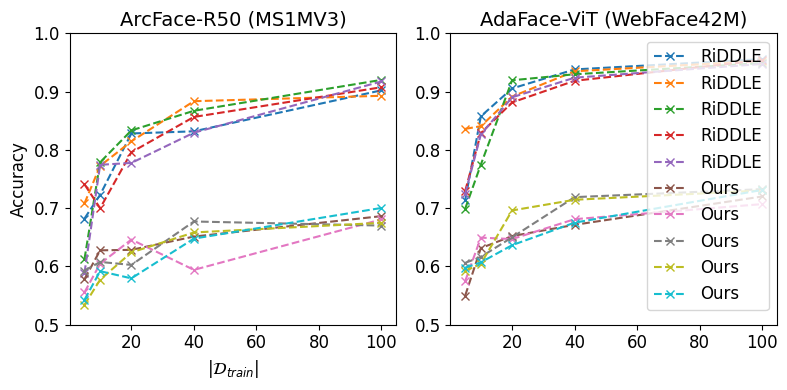

In [8]:
plt.figure(figsize=(2*4,4))
plt.clf()
methods = ["RiDDLE", "controlnet_segmentation_masks_mask_anonymized_face_controlnet_inversion"]
for i, model in enumerate(tested_models):
    plt.subplot(1, len(tested_models), i+1)
    for method in methods:
        if method == "G2Face":
            method_name = "G2Face"
        elif method == "iFADIT":
            method_name = "iFADIT"
        elif method == "RiDDLE":
            method_name = "RiDDLE"
        else:
            method_name = "Ours"
        plt.plot(perf[method][model].keys(), perf[method][model].values(), label = method_name, marker = "x", linestyle="dashed")
        
    if model == tested_models[0]:
        plt.ylabel("Accuracy",fontsize=12)
        plt.xlabel("$|\mathcal{D}_{train}|$",fontsize=12)
    else:
        plt.ylabel("")
        plt.xlabel("")
    if model == tested_models[-1]:
        plt.legend(fontsize=12)
    plt.title(map_models_name[model],fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.ylim(0.5,1)
plt.tight_layout()
plt.show()



In [34]:
import pandas as pd
df_list = []

for method, models in perf.items():
    for model, n_values in models.items():
        for n, scores in n_values.items():
            for s in scores:
                if method == "G2Face":
                    method_name = "G2Face"
                elif method == "iFADIT":
                    method_name = "iFADIT"
                elif method == "RiDDLE":
                    method_name = "RiDDLE"
                else:
                    method_name = "Ours"

                df_list.append({
                    'Method': method_name,
                    'Model': model,
                    'n': n,
                    'Scores': s
                })

df = pd.DataFrame(df_list)

In [35]:
df

,Method,Model,n,Scores
0,RiDDLE,arcface_r50_templates,5,0.679363
1,RiDDLE,arcface_r50_templates,5,0.692799
2,RiDDLE,arcface_r50_templates,5,0.629672
3,RiDDLE,arcface_r50_templates,5,0.640157
4,RiDDLE,arcface_r50_templates,5,0.715003
...,...,...,...,...
95,Ours,adaface_vit_templates,100,0.701839
96,Ours,adaface_vit_templates,100,0.729816
97,Ours,adaface_vit_templates,100,0.740000
98,Ours,adaface_vit_templates,100,0.721037


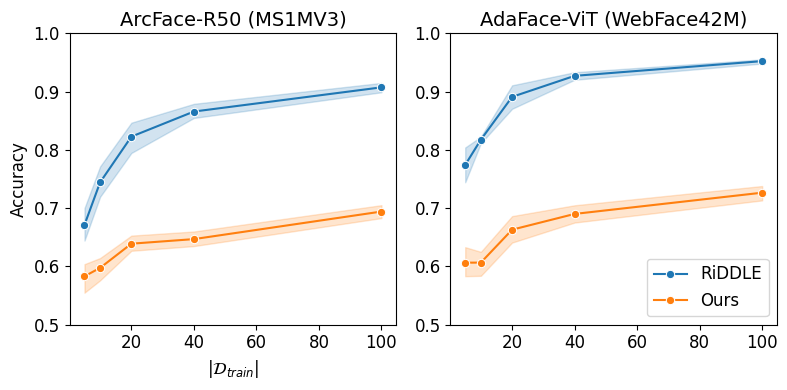

In [36]:
import seaborn as sns
methods = ["RiDDLE", "Ours"]
df = df[df['Method'].isin(methods)]

plt.figure(figsize=(2*4,4))
plt.clf()
for i, model in enumerate(tested_models):
    model_df = df[df['Model'] == model]

    plt.subplot(1, len(tested_models), i+1)
    if model == tested_models[0]:
        sns.lineplot(data=model_df, x='n', y='Scores', hue='Method', marker='o', legend = False)       

        plt.ylabel("Accuracy",fontsize=12)
        plt.xlabel("$|\mathcal{D}_{train}|$",fontsize=12)
    else:
        sns.lineplot(data=model_df, x='n', y='Scores', hue='Method', marker='o')       
        plt.ylabel("")
        plt.xlabel("")
    if model == tested_models[-1]:
        plt.legend(fontsize=12)
    plt.title(map_models_name[model],fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.ylim(0.5,1)
plt.tight_layout()
# plt.savefig(f"figures/TIFS/ano_detector.png", dpi=500)
plt.show()
